# 01b · Exploratory data analysis (EDA)

EDA for the GME / AMC / BB data built in `01_fnspid_meme_news_extraction` and `02_keyword_baseline_sentiment`.
The checks depend on the data type:

| Section | Data | Type | What we look at |
|---|---|---|---|
| A | `fnspid_meme_stocks.csv`, `fnspid_meme_clean.csv` | Text (news articles) | volume over time, sources, text length, missing bodies, duplicates, relevance, vocabulary |
| B | `prices_gme_amc_bb.csv` | Financial time series | price and volume history, return distribution (fat tails), volatility clustering, extreme days |
| C | news × prices | Event / panel data | does news volume move with trading activity? news around the biggest price moves |
| D | `daily_signals_keyword.csv` | Numeric panel (engineered features) | distributions, correlations between signals, coverage |

No GPU needed. Run top to bottom.

## 0. Setup and load

In [1]:
from google.colab import drive
drive.mount('/content/drive')

# ------------------------------------------------------------------
# Project paths: shared Google Drive folder "dl-quant_project"
# Works for the owner and for teammates who added a shortcut to the
# shared folder in their My Drive (see 00_START_HERE_collaboration).
# ------------------------------------------------------------------
import os, glob

def find_project_dir(name="dl-quant_project"):
    candidates = [
        f"/content/drive/MyDrive/Colab Notebooks/{name}",
        f"/content/drive/MyDrive/{name}",
        *glob.glob(f"/content/drive/MyDrive/*/{name}"),
        *glob.glob(f"/content/drive/Shareddrives/*/{name}"),
    ]
    for p in candidates:
        if os.path.isdir(p):
            return p
    raise FileNotFoundError(
        f"Could not find the '{name}' folder in your Google Drive.\n"
        "Fix: Google Drive > Shared with me > right-click 'dl-quant_project' > "
        "Organize > Add shortcut > My Drive. Then re-run this cell.")

PROJECT_DIR  = find_project_dir()
DATA_DIR     = os.path.join(PROJECT_DIR, "DataSource")       # all data files: read AND save here
NOTEBOOK_DIR = os.path.join(PROJECT_DIR, "PythonNoteBooks")  # notebooks
os.makedirs(DATA_DIR, exist_ok=True)
drive_folder = DATA_DIR   # older cells use this name
print("Project folder:", PROJECT_DIR)
print("Data folder:   ", DATA_DIR)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


drive_folder = DATA_DIR  # data folder defined in the setup cell
TICKERS = ["GME", "AMC", "BB"]
COLORS = {"GME": "#e76f51", "AMC": "#2a9d8f", "BB": "#264653"}
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_colwidth", 100)

raw = pd.read_csv(os.path.join(drive_folder, "fnspid_meme_stocks.csv"))
raw["ticker"] = raw["Stock_symbol"].str.upper().str.strip()
raw["date"] = pd.to_datetime(raw["Date"], errors="coerce", utc=True).dt.tz_localize(None).dt.normalize()

clean = pd.read_csv(os.path.join(drive_folder, "fnspid_meme_clean.csv"), parse_dates=["date", "target_date"])

px = pd.read_csv(os.path.join(drive_folder, "prices_gme_amc_bb.csv"),
                 header=[0, 1], index_col=0, parse_dates=True)

signals_path = os.path.join(drive_folder, "daily_signals_keyword.csv")
signals = pd.read_csv(signals_path, parse_dates=["date"]) if os.path.exists(signals_path) else None

for name, df in [("raw news", raw), ("clean news", clean), ("prices (wide)", px), ("signals", signals)]:
    if df is not None:
        print(f"{name:14s} {df.shape}")

Mounted at /content/drive
Project folder: /content/drive/MyDrive/Colab Notebooks/dl-quant_project
Data folder:    /content/drive/MyDrive/Colab Notebooks/dl-quant_project/DataSource
raw news       (14772, 14)
clean news     (9538, 9)
prices (wide)  (3774, 18)
signals        (3745, 13)


In [2]:
# Column types and missing values for each table
def overview(df, name):
    out = pd.DataFrame({"dtype": df.dtypes.astype(str),
                        "missing": df.isna().sum(),
                        "missing_%": (100 * df.isna().mean()).round(1),
                        "n_unique": df.nunique()})
    print(f"\n=== {name} ===")
    print(out.to_string())

overview(raw, "raw news (fnspid_meme_stocks.csv)")
overview(clean, "clean news (fnspid_meme_clean.csv)")
if signals is not None:
    overview(signals, "daily signals (daily_signals_keyword.csv)")


=== raw news (fnspid_meme_stocks.csv) ===
                           dtype  missing  missing_%  n_unique
Unnamed: 0               float64     4708       31.9     10064
Date                      object        0        0.0      3260
Article_title             object        0        0.0     12372
Stock_symbol              object        0        0.0         3
Url                       object        0        0.0     13568
Publisher                 object    10064       68.1       163
Author                   float64    14772      100.0         0
Article                   object     4708       31.9      8878
Lsa_summary               object     4708       31.9      9683
Luhn_summary              object     4708       31.9      9692
Textrank_summary          object     4708       31.9      9690
Lexrank_summary           object     4708       31.9      9704
ticker                    object        0        0.0         3
date              datetime64[ns]        0        0.0      3240

=== clean n

## A. Text data: news articles

### A1. How much news, and when?

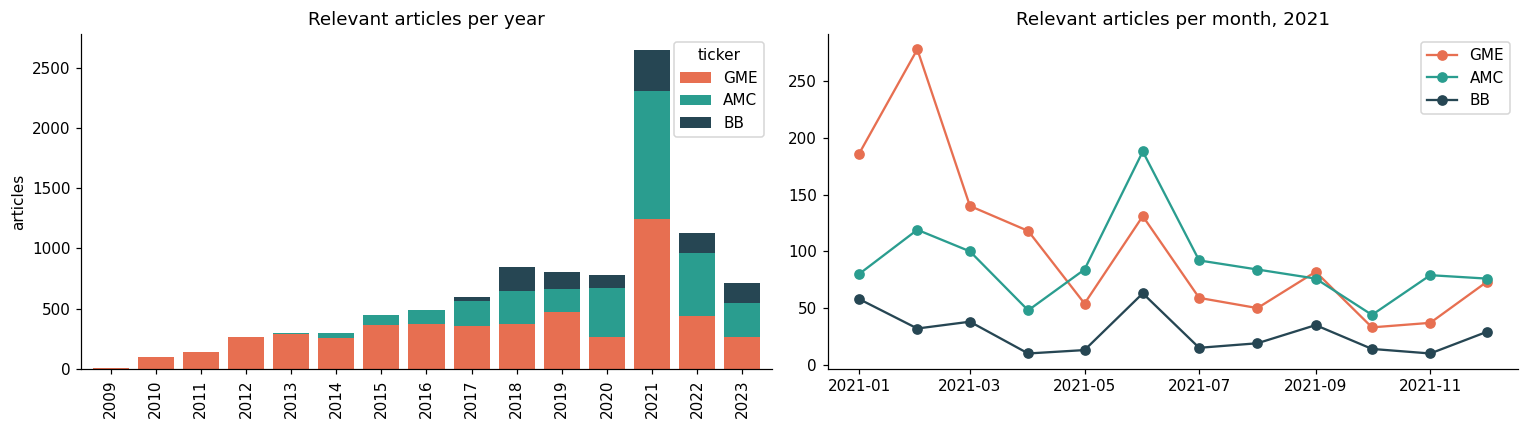

ticker   GME   AMC   BB  total
year                          
2009       8     0    1      9
2010      95     0    0     95
2011     138     1    0    139
2012     263     2    0    265
2013     285     8    0    293
2014     252    43    0    295
2015     362    85    0    447
2016     372   118    0    490
2017     352   213   31    596
2018     372   273  200    845
2019     469   196  140    805
2020     263   407  110    780
2021    1241  1070  336   2647
2022     437   526  161   1124
2023     261   287  160    708


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Articles per year (clean, relevant articles)
yearly = clean.assign(year=clean["date"].dt.year).pivot_table(
    index="year", columns="ticker", values="Url", aggfunc="count", fill_value=0)[TICKERS]
yearly.plot(kind="bar", stacked=True, ax=axes[0], color=[COLORS[t] for t in TICKERS], width=0.8)
axes[0].set_title("Relevant articles per year")
axes[0].set_xlabel(""); axes[0].set_ylabel("articles")

# 2021 by month
c21 = clean[clean["date"].dt.year == 2021]
monthly = c21.assign(month=c21["date"].dt.to_period("M").dt.to_timestamp()).pivot_table(
    index="month", columns="ticker", values="Url", aggfunc="count", fill_value=0)[TICKERS]
for t in TICKERS:
    axes[1].plot(monthly.index, monthly[t], marker="o", color=COLORS[t], label=t)
axes[1].set_title("Relevant articles per month, 2021")
axes[1].legend()
plt.tight_layout(); plt.show()

print(yearly.assign(total=yearly.sum(axis=1)).to_string())

### A2. Who writes it? (publishers)

In [4]:
for t in TICKERS:
    d = clean[clean["ticker"] == t]["Publisher"].fillna("(missing)").value_counts()
    print(f"\n{t}: {d.size} publishers; top 8 cover {100 * d.head(8).sum() / d.sum():.0f}% of articles")
    print((100 * d.head(8) / d.sum()).round(1).rename("share_%").to_string())


GME: 123 publishers; top 8 cover 86% of articles
Publisher
(missing)            60.9
Seeking Alpha         8.2
Paul Quintaro         4.1
Zacks                 3.7
Traders Huddle        2.8
Benzinga Newsdesk     2.4
GuruFocus             1.8
Charles Gross         1.7

AMC: 19 publishers; top 8 cover 98% of articles
Publisher
(missing)            83.9
Seeking Alpha         6.5
Benzinga Newsdesk     2.2
Zacks                 2.0
Paul Quintaro         1.6
GuruFocus             1.0
Hal Lindon            0.8
Vick Meyer            0.5

BB: 1 publishers; top 8 cover 100% of articles
Publisher
(missing)    100.0


### A3. Text length and missing article bodies

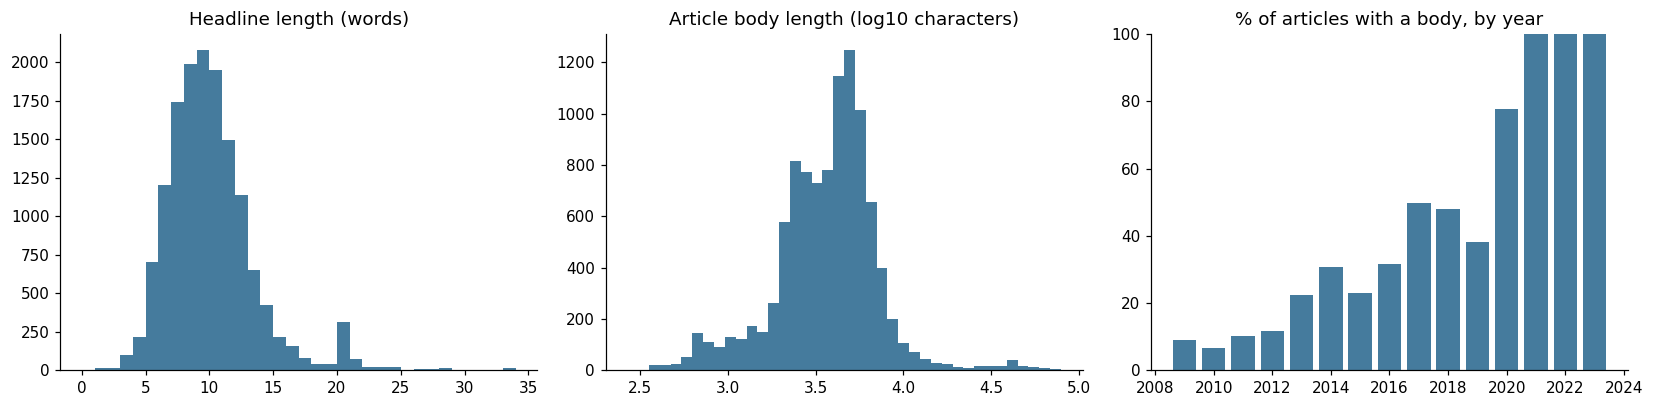

ticker                 AMC       BB      GME
title_words count   5057.0   1480.0   8235.0
            mean      10.0      9.0      9.0
            std        4.0      3.0      4.0
            min        2.0      4.0      1.0
            25%        8.0      8.0      7.0
            50%       10.0      9.0      9.0
            75%       12.0     11.0     11.0
            max       41.0     21.0     50.0
body_chars  count   5057.0   1480.0   8235.0
            mean    3772.0   4584.0   2613.0
            std     4853.0   5413.0   4445.0
            min        0.0    320.0      0.0
            25%     1401.0   2258.0      0.0
            50%     3213.0   3884.0   1555.0
            75%     5073.0   5242.0   4328.0
            max    70922.0  56218.0  79218.0

Share with a body: {'AMC': 0.788, 'BB': 1.0, 'GME': 0.558}


In [5]:
raw["title_words"] = raw["Article_title"].fillna("").str.split().str.len()
raw["body_chars"] = raw["Article"].fillna("").str.len()
raw["has_body"] = raw["body_chars"] > 50

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
axes[0].hist(raw["title_words"], bins=range(0, 35), color="#457b9d")
axes[0].set_title("Headline length (words)")
axes[1].hist(np.log10(raw.loc[raw["has_body"], "body_chars"]), bins=40, color="#457b9d")
axes[1].set_title("Article body length (log10 characters)")
by_year = raw.assign(year=raw["date"].dt.year).groupby("year")["has_body"].mean()
axes[2].bar(by_year.index, 100 * by_year.values, color="#457b9d")
axes[2].set_title("% of articles with a body, by year"); axes[2].set_ylim(0, 100)
plt.tight_layout(); plt.show()

print(raw.groupby("ticker")[["title_words", "body_chars"]].describe().T.round(0).to_string())
print("\nShare with a body:", raw.groupby("ticker")["has_body"].mean().round(3).to_dict())

### A4. Relevance and duplicates

How much of the raw ticker-tagged news is really about the company, and how often the same article is tagged with several tickers.

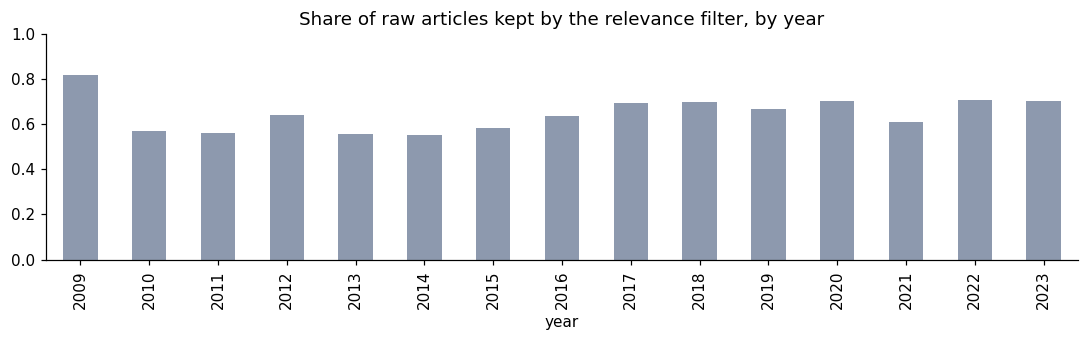

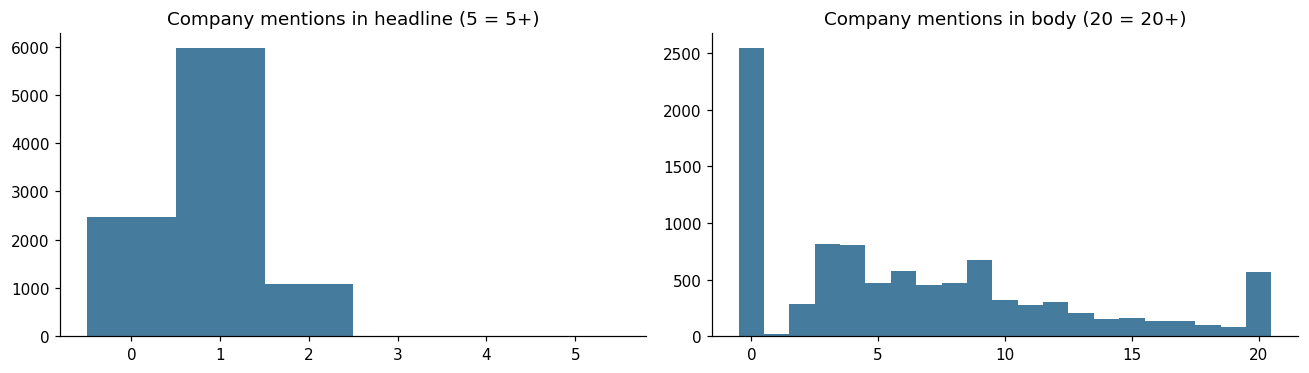

Articles tagged with more than one of GME/AMC/BB: 1040 (7.7% of unique URLs)
Same (ticker, URL) repeated: 39
Same headline repeated within a ticker: 754


In [6]:
kept = clean.assign(year=clean["date"].dt.year).groupby("year").size()
total = raw.assign(year=raw["date"].dt.year).groupby("year").size()
share = (kept / total).rename("kept_share")
ax = share.plot(kind="bar", color="#8d99ae", figsize=(10, 3.2))
ax.set_title("Share of raw articles kept by the relevance filter, by year"); ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].hist(clean["title_hits"].clip(upper=5), bins=np.arange(-0.5, 6), color="#457b9d")
axes[0].set_title("Company mentions in headline (5 = 5+)")
axes[1].hist(clean["body_hits"].clip(upper=20), bins=np.arange(-0.5, 21), color="#457b9d")
axes[1].set_title("Company mentions in body (20 = 20+)")
plt.tight_layout(); plt.show()

urls_per_article = raw.groupby("Url")["ticker"].nunique()
print("Articles tagged with more than one of GME/AMC/BB:", int((urls_per_article > 1).sum()),
      f"({100 * (urls_per_article > 1).mean():.1f}% of unique URLs)")
print("Same (ticker, URL) repeated:", int(raw.duplicated(subset=["ticker", "Url"]).sum()))
print("Same headline repeated within a ticker:", int(clean.duplicated(subset=["ticker", "Article_title"]).sum()))

### A5. Vocabulary: what do the headlines talk about?

Most frequent words and two-word phrases in headlines, 2021 vs. 2015–2019. Shows how the meme episode changed the language.

In [7]:
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

extra_stop = {"stock", "stocks", "shares", "inc", "corp", "nyse", "nasdaq", "today", "week"}
stop = list(ENGLISH_STOP_WORDS | extra_stop)

def top_terms(texts, n=15):
    if len(texts) < 5:
        return pd.Series(dtype=int)
    vec = CountVectorizer(stop_words=stop, ngram_range=(1, 2), min_df=3,
                          token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b")
    X = vec.fit_transform(texts)
    counts = np.asarray(X.sum(axis=0)).ravel()
    return pd.Series(counts, index=vec.get_feature_names_out()).sort_values(ascending=False).head(n)

for t in TICKERS:
    d = clean[clean["ticker"] == t]
    pre = top_terms(d.loc[d["date"].dt.year.between(2015, 2019), "Article_title"].fillna(""))
    y21 = top_terms(d.loc[d["date"].dt.year == 2021, "Article_title"].fillna(""))
    side = pd.DataFrame({"2015-2019": pd.Series([f"{k} ({v})" for k, v in pre.items()], dtype=object),
                         "2021": pd.Series([f"{k} ({v})" for k, v in y21.items()], dtype=object)}).fillna("")
    print(f"\n=== {t}: top headline terms ===")
    print(side.to_string(index=False))


=== GME: top headline terms ===
         2015-2019           2021
   gamestop (1501) gamestop (593)
         gme (428)     meme (124)
    earnings (322)      amc (122)
gamestop gme (209)      gme (120)
       sales (125)   reddit (102)
    dividend (103)       buy (95)
           vs (85)     short (91)
       update (83) robinhood (68)
          buy (80) investors (63)
       report (71)   squeeze (49)
          eps (67)     avoid (45)
       market (66)     rally (42)
       option (64)   trading (40)
 gme earnings (63)    retail (39)
          est (62)    market (37)

=== AMC: top headline terms ===
                   2015-2019                    2021
                   amc (760)               amc (667)
         entertainment (397)     entertainment (188)
     amc entertainment (381) amc entertainment (185)
              earnings (128)          gamestop (105)
              holdings (121)              meme (102)
entertainment holdings (104)                buy (94)
                   

## B. Financial time series: prices and volume

In [8]:
# Wide yfinance table -> long table: one row per ticker x trading day
frames = []
for t in TICKERS:
    d = px.xs(t, axis=1, level=1).copy()
    d.columns = [c.lower().replace(" ", "_") for c in d.columns]
    d["ticker"] = t
    frames.append(d.reset_index().rename(columns={"Date": "date", "index": "date"}))
prices = pd.concat(frames, ignore_index=True)
prices["date"] = pd.to_datetime(prices["date"]).dt.normalize()
prices = prices.dropna(subset=["close"]).sort_values(["ticker", "date"]).reset_index(drop=True)

prices["ret"] = prices.groupby("ticker")["adj_close"].transform(lambda s: np.log(s).diff())
prices["abs_ret"] = prices["ret"].abs()
prices["log_volume"] = np.log1p(prices["volume"])
prices["vol_21d"] = prices.groupby("ticker")["ret"].transform(
    lambda s: s.rolling(21).std() * np.sqrt(252))   # annualized 1-month volatility

summary = prices.groupby("ticker").agg(first_day=("date", "min"), last_day=("date", "max"),
                                       trading_days=("date", "size"),
                                       zero_volume_days=("volume", lambda v: int((v == 0).sum())))
print(summary.to_string())

        first_day   last_day  trading_days  zero_volume_days
ticker                                                      
AMC    2013-12-18 2023-12-29          2525                 0
BB     2009-01-02 2023-12-29          3774                 0
GME    2009-01-02 2023-12-29          3774                 0


### B1. Price and volume history (2021 shaded)

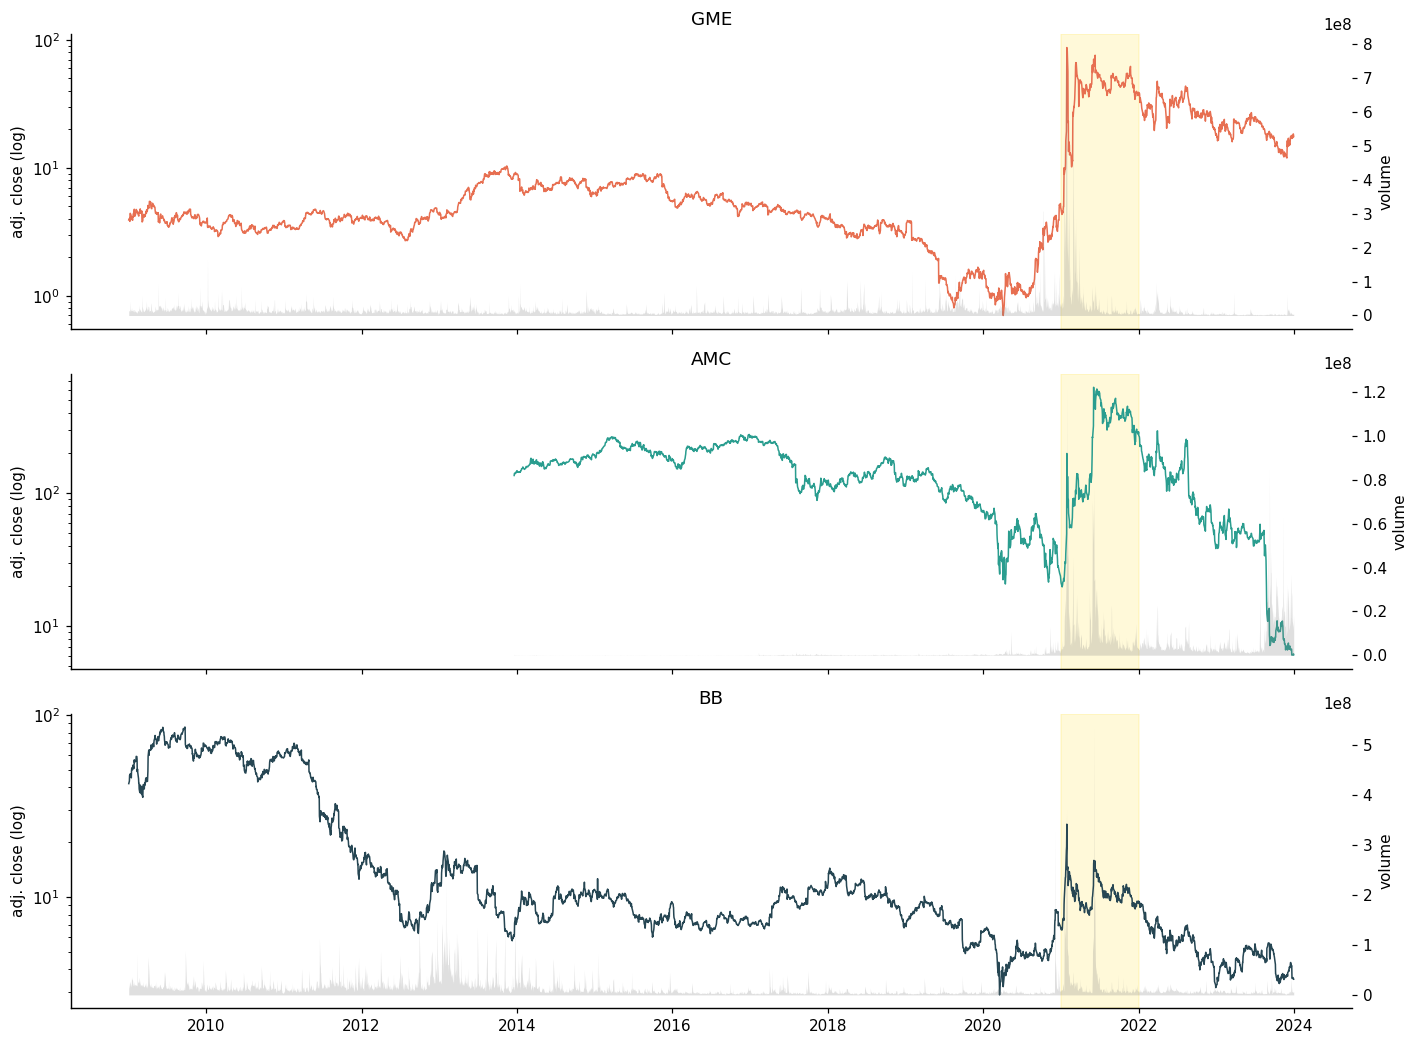

In [9]:
fig, axes = plt.subplots(len(TICKERS), 1, figsize=(13, 3.2 * len(TICKERS)), sharex=True)
for ax, t in zip(axes, TICKERS):
    d = prices[prices["ticker"] == t]
    ax.plot(d["date"], d["adj_close"], color=COLORS[t], lw=1)
    ax.set_yscale("log"); ax.set_ylabel("adj. close (log)")
    ax2 = ax.twinx()
    ax2.fill_between(d["date"], d["volume"], color="grey", alpha=0.25, lw=0)
    ax2.set_ylabel("volume")
    ax.axvspan(pd.Timestamp("2021-01-01"), pd.Timestamp("2021-12-31"), color="gold", alpha=0.15)
    ax.set_title(t)
plt.tight_layout(); plt.show()

### B2. Return distribution

Meme stocks are expected to have very fat tails (kurtosis far above the normal distribution's 3).

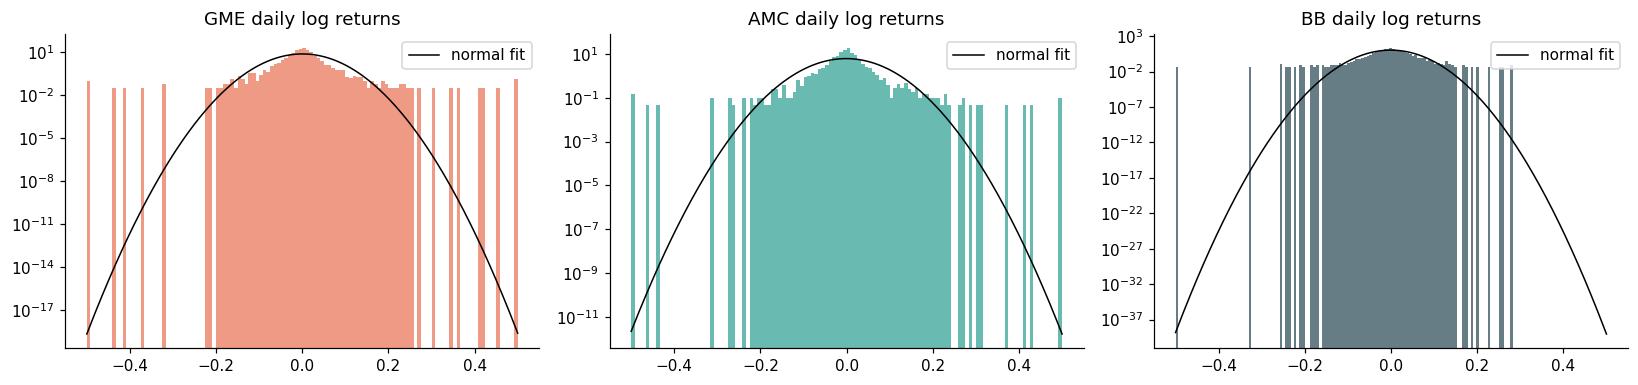

ticker period  mean_%  std_%  skew  kurtosis  days_|ret|>10%
   GME    all    0.04   5.27  0.83     78.63             124
   GME   2021    0.82  14.75  0.41     18.08              43
   AMC    all   -0.12   6.59  3.04    103.43             147
   AMC   2021    1.01  14.32  3.10     42.57              49
    BB    all   -0.07   3.68 -0.98     25.51              73
    BB   2021    0.14   6.52 -1.24     24.52              14


In [10]:
from scipy import stats

fig, axes = plt.subplots(1, len(TICKERS), figsize=(15, 3.6))
rows = []
for ax, t in zip(axes, TICKERS):
    r = prices.loc[prices["ticker"] == t, "ret"].dropna()
    ax.hist(r.clip(-0.5, 0.5), bins=120, density=True, color=COLORS[t], alpha=0.7)
    x = np.linspace(-0.5, 0.5, 400)
    ax.plot(x, stats.norm.pdf(x, r.mean(), r.std()), color="black", lw=1, label="normal fit")
    ax.set_yscale("log"); ax.set_title(f"{t} daily log returns"); ax.legend()
    for period, rr in [("all", r), ("2021", prices.loc[(prices["ticker"] == t) &
                                                       (prices["date"].dt.year == 2021), "ret"].dropna())]:
        rows.append({"ticker": t, "period": period, "mean_%": 100 * rr.mean(), "std_%": 100 * rr.std(),
                     "skew": stats.skew(rr), "kurtosis": stats.kurtosis(rr, fisher=False),
                     "days_|ret|>10%": int((rr.abs() > 0.10).sum())})
plt.tight_layout(); plt.show()
print(pd.DataFrame(rows).round(2).to_string(index=False))

### B3. Volatility clustering

If |returns| are autocorrelated, big moves follow big moves. This is why HAR-type volatility baselines work.

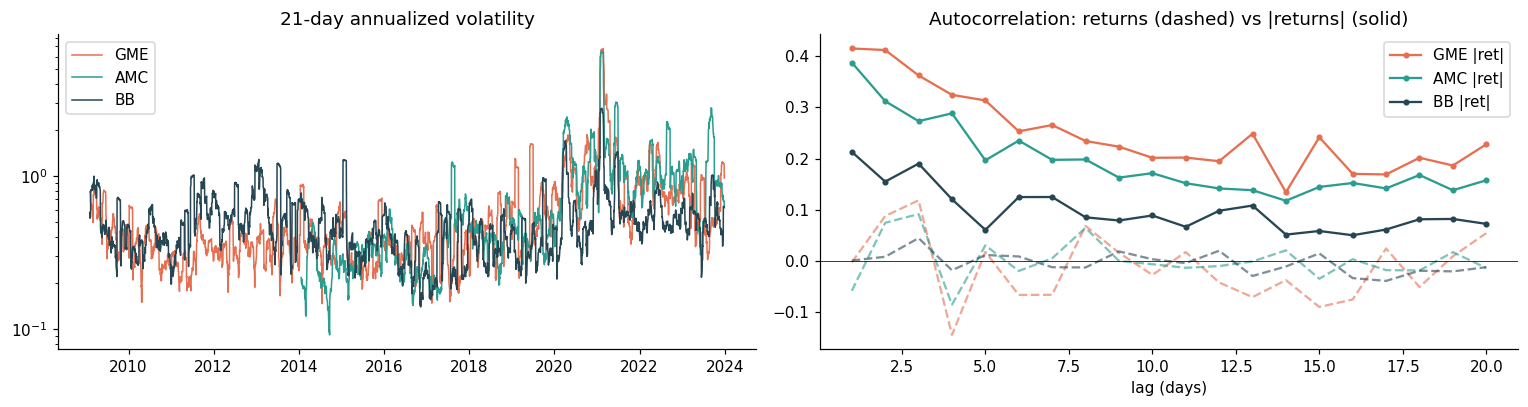

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
for t in TICKERS:
    d = prices[prices["ticker"] == t]
    axes[0].plot(d["date"], d["vol_21d"], color=COLORS[t], lw=1, label=t)
    r = d["ret"].dropna()
    lags = range(1, 21)
    axes[1].plot(lags, [r.autocorr(l) for l in lags], "--", color=COLORS[t], alpha=0.6)
    axes[1].plot(lags, [r.abs().autocorr(l) for l in lags], "-o", ms=3, color=COLORS[t], label=f"{t} |ret|")
axes[0].set_yscale("log"); axes[0].set_title("21-day annualized volatility"); axes[0].legend()
axes[1].axhline(0, color="black", lw=0.5)
axes[1].set_title("Autocorrelation: returns (dashed) vs |returns| (solid)"); axes[1].set_xlabel("lag (days)")
axes[1].legend()
plt.tight_layout(); plt.show()

### B4. The most extreme days

In [12]:
extreme = (prices.dropna(subset=["ret"])
                 .sort_values("abs_ret", ascending=False)
                 .groupby("ticker").head(5)
                 .sort_values(["ticker", "abs_ret"], ascending=[True, False]))
extreme = extreme.assign(ret_pct=(100 * (np.exp(extreme["ret"]) - 1)).round(1))
print(extreme[["ticker", "date", "ret_pct", "volume", "adj_close"]].to_string(index=False))

ticker       date  ret_pct      volume  adj_close
   AMC 2021-01-27    301.2 122234250.0 199.000000
   AMC 2021-01-28    -56.6  59122390.0  86.300003
   AMC 2021-06-02     95.2  76646250.0 625.500000
   AMC 2022-08-22    -42.0  15115870.0 104.599998
   AMC 2021-02-02    -41.2  46277590.0  78.199997
    BB 2021-01-28    -41.6 194906600.0  14.650000
    BB 2013-06-28    -27.8 136025600.0  10.460000
    BB 2021-01-27     32.7 372222600.0  25.100000
    BB 2021-06-02     31.9 346138300.0  15.250000
    BB 2015-01-14     29.8  83543900.0  12.600000
   GME 2021-02-02    -60.0 312732400.0  22.500000
   GME 2021-01-27    134.8 373586800.0  86.877502
   GME 2021-02-24    103.9 332446800.0  22.927500
   GME 2021-01-26     92.7 714352000.0  36.994999
   GME 2021-01-28    -44.3 235263200.0  48.400002


## C. News × market

Uses each article's **publication date** mapped to the same or next trading day (descriptive only; the modelling notebooks use `target_date` = D+1 to avoid look-ahead).

/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/tmp/ipykernel_1541/2714214215.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: pd.Series({


       corr_n_logvol             corr_n_absret             days_with_news_%              
ticker           AMC    BB   GME           AMC    BB   GME              AMC     BB    GME
year                                                                                     
2009             NaN -0.06  0.06           NaN -0.06 -0.06              NaN   0.40   2.38
2010             NaN   NaN  0.45           NaN   NaN  0.36              NaN   0.00  19.05
2011             NaN   NaN  0.39           NaN   NaN  0.17              NaN   0.00  29.37
2012             NaN   NaN  0.46           NaN   NaN  0.35              NaN   0.00  51.60
2013            0.72   NaN  0.42         -0.22   NaN  0.28            22.22   0.00  54.76
2014            0.06   NaN  0.35          0.04   NaN  0.33            10.71   0.00  41.67
2015            0.12   NaN  0.53          0.13   NaN  0.33            22.22   0.00  52.78
2016            0.21   NaN  0.45          0.26   NaN  0.28            29.37   0.00  55.56
2017      

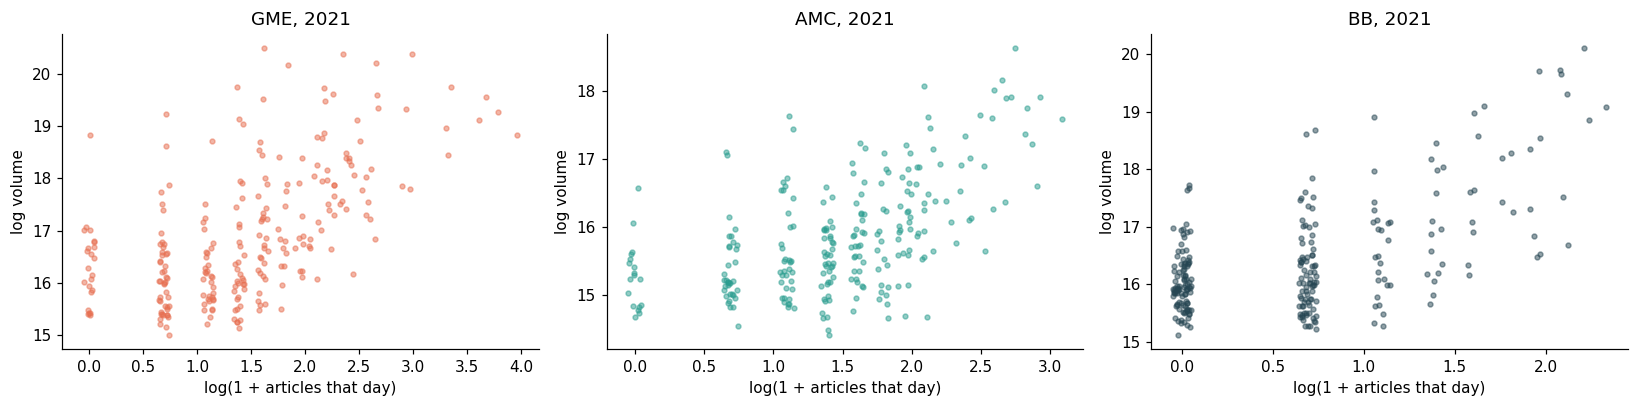

In [13]:
trading_days = np.array(sorted(prices["date"].unique()), dtype="datetime64[ns]")
pos = np.searchsorted(trading_days, clean["date"].values.astype("datetime64[ns]"), side="left")
ok = pos < len(trading_days)
news_td = clean[ok].assign(trade_day=trading_days[pos[ok]])
daily_n = news_td.groupby(["ticker", "trade_day"]).size().rename("n_articles").reset_index()

panel = prices.merge(daily_n, left_on=["ticker", "date"], right_on=["ticker", "trade_day"], how="left")
panel["n_articles"] = panel["n_articles"].fillna(0)
panel["year"] = panel["date"].dt.year

corr_year = (panel.groupby(["ticker", "year"])
                  .apply(lambda d: pd.Series({
                      "corr_n_logvol": np.log1p(d["n_articles"]).corr(d["log_volume"]),
                      "corr_n_absret": np.log1p(d["n_articles"]).corr(d["abs_ret"]),
                      "days_with_news_%": 100 * (d["n_articles"] > 0).mean()}))
                  .round(2))
print(corr_year.unstack("ticker").to_string())

p21 = panel[panel["year"] == 2021]
fig, axes = plt.subplots(1, len(TICKERS), figsize=(15, 3.8), sharey=False)
for ax, t in zip(axes, TICKERS):
    d = p21[p21["ticker"] == t]
    ax.scatter(np.log1p(d["n_articles"]) + np.random.uniform(-0.05, 0.05, len(d)), d["log_volume"],
               s=10, alpha=0.5, color=COLORS[t])
    ax.set_xlabel("log(1 + articles that day)"); ax.set_ylabel("log volume"); ax.set_title(f"{t}, 2021")
plt.tight_layout(); plt.show()

### C1. News around the biggest price moves (event study)

Average number of articles from 5 trading days before to 5 days after each ticker's 20 largest |return| days.
Rising **before** day 0 would suggest news leads moves; rising mostly **after** suggests news reacts to moves.

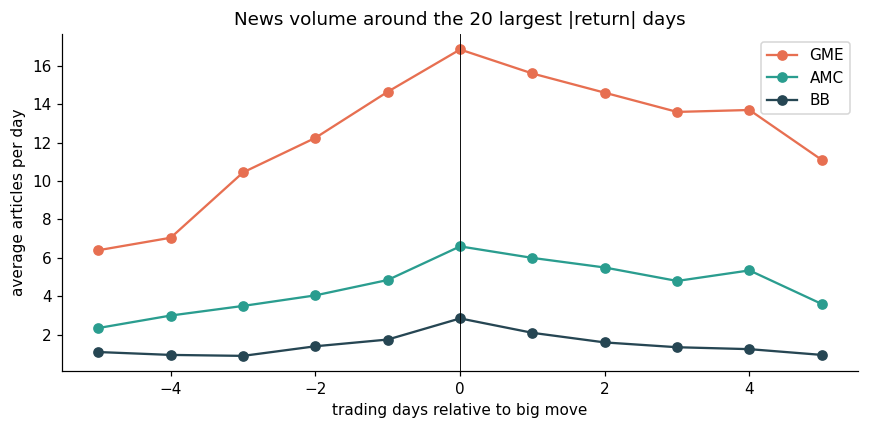

       -5    -4     -3     -2     -1      0     1     2      3      4      5
GME  6.40  7.05  10.45  12.25  14.65  16.85  15.6  14.6  13.60  13.70  11.10
AMC  2.35  3.00   3.50   4.05   4.85   6.60   6.0   5.5   4.80   5.35   3.60
BB   1.10  0.95   0.90   1.40   1.75   2.85   2.1   1.6   1.35   1.25   0.95


In [14]:
window = range(-5, 6)
curves = {}
for t in TICKERS:
    d = panel[panel["ticker"] == t].reset_index(drop=True)
    events = d.dropna(subset=["abs_ret"]).nlargest(20, "abs_ret").index
    mat = []
    for i in events:
        idx = [i + k for k in window]
        if min(idx) >= 0 and max(idx) < len(d):
            mat.append(d.loc[idx, "n_articles"].to_numpy())
    curves[t] = np.mean(mat, axis=0) if mat else np.full(len(window), np.nan)

plt.figure(figsize=(8, 4))
for t in TICKERS:
    plt.plot(list(window), curves[t], "-o", color=COLORS[t], label=t)
plt.axvline(0, color="black", lw=0.6)
plt.xlabel("trading days relative to big move"); plt.ylabel("average articles per day")
plt.title("News volume around the 20 largest |return| days"); plt.legend()
plt.tight_layout(); plt.show()
print(pd.DataFrame(curves, index=list(window)).round(2).T.to_string())

## D. Engineered daily signals (keyword baseline)

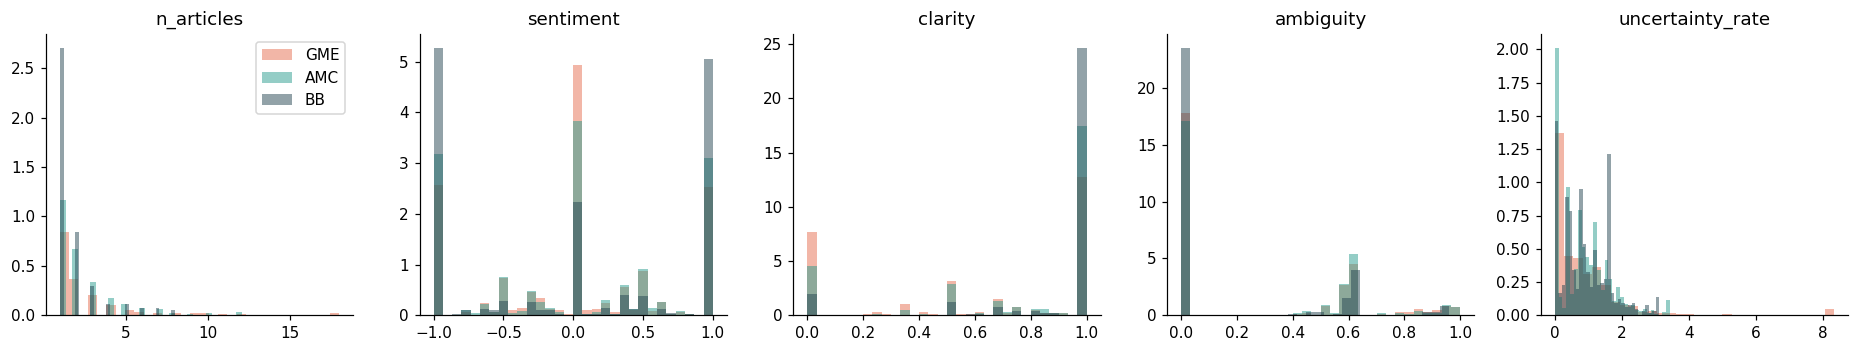

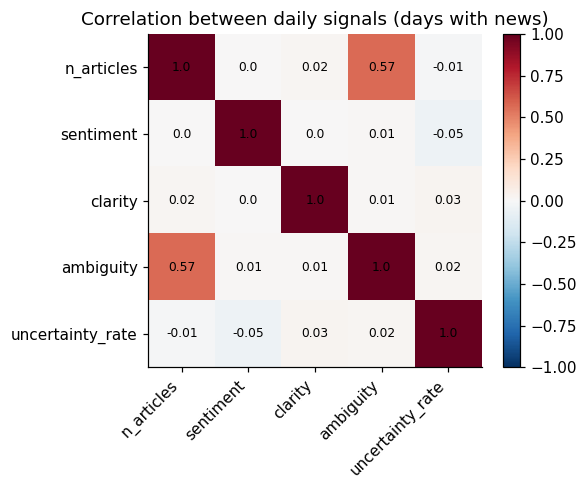

In [15]:
if signals is None:
    print("daily_signals_keyword.csv not found. Run 02_keyword_baseline_sentiment first.")
else:
    cols = ["n_articles", "sentiment", "clarity", "ambiguity", "uncertainty_rate"]
    fig, axes = plt.subplots(1, len(cols), figsize=(17, 3.3))
    for ax, c in zip(axes, cols):
        for t in TICKERS:
            v = signals.loc[signals["ticker"] == t, c]
            ax.hist(v.clip(upper=v.quantile(0.99)), bins=30, alpha=0.5, color=COLORS[t], label=t, density=True)
        ax.set_title(c)
    axes[0].legend()
    plt.tight_layout(); plt.show()

    corr = signals[cols].corr().round(2)
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=45, ha="right")
    ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols)
    for i in range(len(cols)):
        for j in range(len(cols)):
            ax.text(j, i, corr.iloc[i, j], ha="center", va="center", fontsize=8)
    plt.colorbar(im); ax.set_title("Correlation between daily signals (days with news)")
    plt.tight_layout(); plt.show()

### D1. Is ambiguity just a proxy for news volume?

With hard (one-hot) keyword labels, a day with a single article always has ambiguity 0. This checks how strongly ambiguity depends on the number of articles, which is why later regressions must control for text volume.

In [16]:
if signals is not None:
    b = pd.cut(signals["n_articles"], bins=[0, 1, 2, 3, 5, 10, np.inf],
               labels=["1", "2", "3", "4-5", "6-10", "11+"])
    tab = signals.groupby(b, observed=True).agg(days=("ambiguity", "size"),
                                                mean_ambiguity=("ambiguity", "mean"),
                                                mean_clarity=("clarity", "mean"),
                                                mean_sentiment=("sentiment", "mean")).round(3)
    print(tab.to_string())
    print("\nCorrelation(ambiguity, log n_articles):",
          round(signals["ambiguity"].corr(np.log1p(signals["n_articles"])), 3))

            days  mean_ambiguity  mean_clarity  mean_sentiment
n_articles                                                    
1           1821           0.000         0.694          -0.035
2            819           0.359         0.687           0.051
3            420           0.528         0.718           0.031
4-5          343           0.628         0.728           0.033
6-10         256           0.707         0.745           0.034
11+           86           0.765         0.674          -0.045

Correlation(ambiguity, log n_articles): 0.751


## Key takeaways

**Text (news)**
- 9,538 relevant articles; **2021 has 2,647 (28%)**, about 3× 2020. GME dominates (5,170), BB is small (1,139).
- **BB has no articles before 2017.** BlackBerry traded as BBRY until 2016, so earlier news is probably filed under that ticker (not checked yet).
- `Publisher` is missing for 73% of clean articles (100% for BB), so it cannot be used as a feature.
- Headlines are short (median 9–10 words). A body exists for 68% of raw articles, rising from roughly 10–20% before 2014 to ~100% from 2021, so the text type changes over time.
- **754 repeated headlines within a ticker** (syndicated copies with different URLs) → also dedupe on (ticker, headline, date).
- **Vocabulary shift:** 2015–2019 headlines are about earnings, sales, dividends; 2021 headlines are about *meme, reddit, short, squeeze, robinhood, rally, avoid*, and each stock's headlines mention the others (AMC ↔ GameStop). This supports a meme-specific (domain-adapted) sentiment model.

**Prices**
- GME and BB from 2009, AMC from its Dec 2013 IPO; no zero-volume days.
- **Extremely fat tails:** kurtosis 79 (GME), 103 (AMC), 26 (BB) vs 3 for a normal distribution. In 2021 the daily return std was ~15% for GME and AMC. The largest moves are all in Jan–Jun 2021 (e.g. AMC +301% and GME +135% on 2021-01-27).
- **Volatility clustering:** |return| autocorrelation at lag 1 is ~0.41 (GME), ~0.37 (AMC), ~0.22 (BB) and decays slowly, while raw returns have ~0 autocorrelation. Volatility and volume are predictable, direction is not, which supports the project's focus on volatility and volume.

**News × market**
- Correlation between log(1 + daily articles) and log volume is positive in almost every year and **0.55–0.58 for all three stocks in 2021**.
- **Event study:** news volume rises steadily over the 5 days before the 20 largest moves (GME: 6.4 → 16.9 articles/day at day 0) and decays after. Caveat: the big moves cluster in Jan–Feb 2021, so event windows overlap; this is not yet evidence that news leads prices.

**Signals (keyword baseline)**
- 1,821 of 3,745 news-days have a single article.
- **Ambiguity is largely a proxy for article count:** 0 on single-article days, 0.36 with 2 articles, 0.77 with 11+ (corr with log n_articles = 0.75). Later models must control for text volume, or use soft FinBERT probabilities.
- `uncertainty_rate` is almost uncorrelated with the other signals, so it carries separate information.

**Implications**
1. Add title-based deduplication; check BBRY for pre-2017 BlackBerry news.
2. Use robust losses (QLIKE / log targets) and consider winsorizing returns because of the fat tails.
3. Always include n_articles as a control when testing clarity and ambiguity.